In [1]:
import pandas as pd 
import numpy as np
import random
import os 
import argparse
import json
import torch
import pickle
import matplotlib.pyplot as plt
from torch import nn
from attrdict import AttrDict
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
from torch.utils.data import TensorDataset
from transformers import BertForSequenceClassification
from transformers import BertConfig, BertTokenizer, BertModel
from torchmetrics import R2Score
from sklearn.metrics import precision_score , recall_score , confusion_matrix, f1_score, classification_report

In [2]:
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="3"

In [3]:
default_path = os.getcwd()
data_path = os.path.join(default_path, '../data')
base_model = os.path.join(default_path, '../base-model')
config_path = os.path.join(default_path, '../config')
log_path = os.path.join(default_path, '../log')
model_path = os.path.join(default_path, '../models')
config_file = "bert-base.json"

In [4]:
X_train = pd.read_csv(os.path.join(data_path, 'emodep_train.csv'))
X_dev = pd.read_csv(os.path.join(data_path, 'emodep_val.csv'))
X_test = pd.read_csv(os.path.join(data_path, 'emodep_test.csv'))

In [5]:
X_train = X_train[['author', 'text', 'type', 'criteria']]
X_dev = X_dev[['author', 'text', 'type', 'criteria']]
X_test = X_test[['author', 'text', 'type', 'criteria']]

X_train.columns = ['author', 'text', 'type', 'label']
X_dev.columns = ['author', 'text', 'type', 'label']
X_test.columns = ['author', 'text', 'type', 'label']

In [6]:
X_train.head(3)

,author,text,type,label
0,fuckaspergers,IDK I was diagnosed with this accursed disorder,comment,4
1,UncertaintyLich,I thought it was a miserable pile of secrets,comment,6
2,Suffocation976,It is just pissing me off making me more sad ...,post,0


#### Define Class 

In [7]:
class BertDataset(Dataset):
    def __init__(self, data_file):
        self.data = data_file
    
    def __len__(self):
        return len(self.data.label)
    
    def reset_index(self):
        self.data.reset_index(inplace=True, drop=True)
    
    def __getitem__(self, idx):
        '''
        return text, label
        '''
        self.reset_index()
        text = self.data.text[idx]
        label = self.data.label[idx]
        return text, label

In [8]:
class BertProcessor():
    def __init__(self, config, training_config, tokenizer, truncation=True):
        self.tokenizer = tokenizer 
        self.max_len = config.max_position_embeddings
        self.pad = training_config.pad
        self.batch_size = training_config.train_batch_size
        self.truncation = truncation
    
    def convert_data(self, data_file):
        context2 = None    # single sentence classification
        batch_encoding = self.tokenizer.batch_encode_plus(
            [(data_file[idx][0], context2) for idx in range(len(data_file))],   # text, 
            max_length = self.max_len,
            padding = self.pad,
            truncation = self.truncation
        )
        
        features = []
        for i in range(len(data_file)):
            inputs = {k: batch_encoding[k][i] for k in batch_encoding}
            try:
                inputs['label'] = data_file[i][1] 
            except:
                # print('input label 오류')
                inputs['label'] = 0 
            features.append(inputs)
        
        all_input_ids = torch.tensor([f['input_ids'] for f in features], dtype=torch.long)
        all_attention_mask = torch.tensor([f['attention_mask'] for f in features], dtype=torch.long)
        all_token_type_ids = torch.tensor([f['token_type_ids'] for f in features], dtype=torch.long)
        all_labels = torch.tensor([f['label'] for f in features], dtype=torch.long)

        dataset = TensorDataset(all_input_ids, all_attention_mask, all_token_type_ids, all_labels)
        return dataset
    
    def shuffle_data(self, dataset, data_type):
        if data_type == 'train':
            return RandomSampler(dataset)
        elif data_type == 'eval' or data_type == 'test':
            return SequentialSampler(dataset)
        
    def load_data(self, dataset, sampler):
        return DataLoader(dataset, sampler=sampler, batch_size=self.batch_size)

In [9]:
class BertClsTester():
    def __init__(self, training_config, model):
        self.training_config = training_config
        self.model = model

    def get_label(self, test_dataloader, test_type):
        '''
        test_type: 0  -> Test dataset 
        test_type: 1  -> Test sentence
        '''
        preds = []
        labels = []

        for batch in test_dataloader:
            self.model.eval()
            batch = tuple(t.to(self.training_config.device) for t in batch)   # args.device: cuda 
            with torch.no_grad():
                inputs = {
                    "input_ids": batch[0],
                    "attention_mask": batch[1],
                    "token_type_ids": batch[2],
                    "labels": batch[3]
                }
                outputs = self.model(**inputs)
                test_loss, logits = outputs[:2] 
                pred = logits.detach().cpu().numpy()
                if test_type == 0:
                    preds.extend(np.argmax(pred, axis=1))
                elif test_type == 1:
                    preds.append(np.argmax(pred))  
            label = inputs["labels"].detach().cpu().numpy()
            labels.extend(label)
        return preds, labels 
    
    def get_f1_score(self, test_dataloader):
        y_pred, y_true = self.get_label(test_dataloader)
        return round(f1_score(y_true, y_pred, average='micro'), 3) 
     
    def get_cl_report(self, test_dataloader):
        y_pred, y_true = self.get_label(test_dataloader, 0)
        cr = classification_report(y_true, y_pred).split('\n')
        clr_df = []

        for idx, line in enumerate(cr):
            clr_df.append([])
            if line == '':
                continue

            word_list = line.strip().split(' ')

            for word in word_list:
                if word != '':
                    clr_df[idx].append(word)

        clr_df[-2][0] = ' '.join([clr_df[-2][0], clr_df[-2][1]])
        clr_df[-3][0] = ' '.join([clr_df[-3][0], clr_df[-3][1]])
        clr_df[-4].insert(1, ' ')
        clr_df[-4].insert(2, ' ')
        clr_df[0].insert(0, 'index')

        clr_df[-2].pop(1)
        clr_df[-3].pop(1)
        clr_df.pop(1)
        clr_df.pop(-1)
        clr_df.pop(-4)
        clr_df = pd.DataFrame(clr_df[1:], columns=clr_df[0])
        clr_df.index = clr_df['index']

        del clr_df['index']
        return clr_df

### Load Trained Model (BERT)

In [10]:
with open(os.path.join(config_path, 'training_config.json')) as f:
    training_config = AttrDict(json.load(f))

In [11]:
training_config.device = torch.device("cuda") if torch.cuda.is_available() else "cpu"
training_config.config_path = config_path
training_config.log_path = log_path
training_config.data_path = data_path
training_config.model_path = model_path 
training_config.pad = 'max_length'
training_config.num_epochs = 5

In [12]:
tokenizer = BertTokenizer.from_pretrained(os.path.join(base_model, 'bert-base'), model_max_length=128)
config = BertConfig.from_pretrained(os.path.join(base_model, 'bert-base', 'bert_config.json'), num_labels=9, output_hidden_states=True)

In [13]:
# p_model = f'bert_emodep_untagged_a{criteria}.pt'
# p_model = f'bert_untagged_a{criteria}_eval.pt'
p_model = f'bert_emodep_e5.pt'

In [14]:
model = BertForSequenceClassification.from_pretrained(os.path.join(base_model, 'bert-base'), config=config)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at /home/pbl1/pseudo-labeling/jupyter/../base-model/bert-base and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [15]:
config.max_position_embeddings = 128
config.max_position_embeddings

128

In [16]:
model.load_state_dict(torch.load(os.path.join(model_path, p_model)))
model.to(training_config.device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

### Data Transform 

In [17]:
bert_processor = BertProcessor(config, training_config, tokenizer)

In [18]:
test_file = BertDataset(X_test)
test_dataset = bert_processor.convert_data(test_file)
test_sampler = bert_processor.shuffle_data(test_dataset, 'test')
test_dataloader = bert_processor.load_data(test_dataset, test_sampler)

### Data Test 

In [19]:
bert_tester = BertClsTester(training_config, model)

In [20]:
dsm_pred, dsm_true = bert_tester.get_label(test_dataloader, 0)

In [21]:
from torchmetrics.classification import F1Score
from torchmetrics.classification import MulticlassPrecision
from torchmetrics.classification import MulticlassRecall
from torchmetrics.classification import MulticlassSpecificity

f1 = F1Score(task="multiclass", num_classes=len(X_test.label.unique()))
precision = MulticlassPrecision(num_classes=len(X_test.label.unique()))
recall = MulticlassRecall(num_classes=len(X_test.label.unique()))
specificity = MulticlassSpecificity(num_classes=len(X_test.label.unique()))

In [24]:
print(f'precision: {precision(torch.Tensor(dsm_pred), torch.Tensor(dsm_true))}')
print(f'recall: {recall(torch.Tensor(dsm_pred), torch.Tensor(dsm_true))}')
print(f'specificity: {specificity(torch.Tensor(dsm_pred), torch.Tensor(dsm_true))}')
print(f'f1-score: {f1(torch.Tensor(dsm_pred), torch.Tensor(dsm_true))}')

precision: 0.9182771444320679
recall: 0.9056429862976074
specificity: 0.9914525747299194
f1-score: 0.9454118609428406


In [25]:
labels = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']

In [26]:
import seaborn as sns
import matplotlib.colors as mcl
from sklearn.metrics import confusion_matrix

In [27]:
cm = confusion_matrix(dsm_true, dsm_pred)

In [28]:
cm_df = pd.DataFrame(cm,
     index = labels, 
     columns = labels)

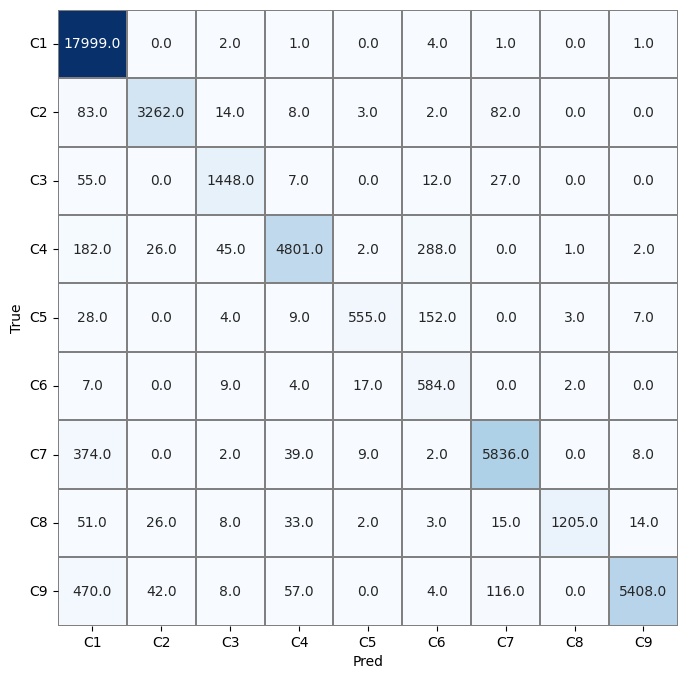

In [29]:
plt.figure(figsize=(8,8))
sns.heatmap(cm_df, cmap='Blues', annot=True, fmt=".1f", cbar=False, linewidth=0.1, linecolor='grey', xticklabels='auto')
# plt.title('Confusion Matrix of major depression disorder criteria classification')
plt.ylabel('True')
plt.yticks(rotation=0)
plt.xlabel('Pred')
plt.show()